In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", 
                   index_col= "datetime", parse_dates= True)

data.head(), data.info(), data.shape

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21983 entries, 2022-01-01 00:00:00 to 2024-07-04 23:00:00
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Kwh               21983 non-null  float64
 1   name              21983 non-null  object 
 2   temp              21983 non-null  float64
 3   feelslike         21983 non-null  float64
 4   dew               21983 non-null  float64
 5   humidity          21983 non-null  float64
 6   precip            21983 non-null  float64
 7   snow              21930 non-null  float64
 8   snowdepth         21983 non-null  float64
 9   windgust          21983 non-null  float64
 10  windspeed         21983 non-null  float64
 11  winddir           21983 non-null  float64
 12  sealevelpressure  21983 non-null  float64
 13  cloudcover        21983 non-null  float64
 14  visibility        21705 non-null  float64
 15  solarradiation    21982 non-null  float64
 16  solar

(                         Kwh            name     temp  feelslike      dew  \
 datetime                                                                    
 2022-01-01 00:00:00 0.000000  Kozani, Greece 6.000000   4.400000 2.000000   
 2022-01-01 01:00:00 0.000000  Kozani, Greece 6.000000   5.000000 2.000000   
 2022-01-01 02:00:00 0.000000  Kozani, Greece 4.900000   3.200000 2.000000   
 2022-01-01 03:00:00 0.000000  Kozani, Greece 4.000000   4.000000 1.000000   
 2022-01-01 04:00:00 0.000000  Kozani, Greece 3.000000   1.600000 2.000000   
 
                      humidity   precip     snow  snowdepth  windgust  \
 datetime                                                               
 2022-01-01 00:00:00 75.510000 0.000000 0.000000   0.000000 19.800000   
 2022-01-01 01:00:00 75.510000 0.000000 0.000000   0.000000 19.800000   
 2022-01-01 02:00:00 81.610000 0.000000      NaN   0.000000 20.500000   
 2022-01-01 03:00:00 80.800000 0.000000      NaN   0.000000 20.500000   
 2022-01-01 04

In [44]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()
data['solarradiation'].fillna(mean_13_00, inplace=True)

df_13_00, mean_13_00

(                         Kwh            name      temp  feelslike       dew  \
 datetime                                                                      
 2022-01-01 13:00:00 0.426300  Kozani, Greece 14.000000  14.000000  3.000000   
 2022-01-02 13:00:00 0.439100  Kozani, Greece 14.000000  14.000000  1.000000   
 2022-01-03 13:00:00 0.442100  Kozani, Greece 13.000000  13.000000  3.000000   
 2022-01-04 13:00:00 0.461100  Kozani, Greece 11.000000  11.000000  0.000000   
 2022-01-05 13:00:00 0.439700  Kozani, Greece 14.000000  14.000000  2.000000   
 ...                      ...             ...       ...        ...       ...   
 2024-06-30 13:00:00 0.688300  Kozani, Greece 31.000000  29.100000  7.000000   
 2024-07-01 13:00:00 0.690600  Kozani, Greece 33.900000  32.200000 10.600000   
 2024-07-02 13:00:00 0.458200  Kozani, Greece 31.000000  29.500000 10.000000   
 2024-07-03 13:00:00 0.747200  Kozani, Greece 25.000000  25.000000  9.000000   
 2024-07-04 13:00:00 0.669200  Kozani, G

# Exploratory Data Analysis

### Summary Statistics

In [45]:
data_non_zero = data[data['Kwh'] != 0]
data_non_zero

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 08:00:00,0.030500,"Kozani, Greece",5.000000,1.800000,2.000000,80.950000,0.000000,0.000000,0.000000,22.300000,14.700000,340.000000,1021.000000,49.900000,10.000000,6.000000,0.000000,0.000000,Partially cloudy,partly-cloudy-day
2022-01-01 09:00:00,0.099100,"Kozani, Greece",6.000000,3.600000,3.000000,81.080000,0.000000,0.000000,0.000000,23.000000,11.200000,290.000000,1021.000000,50.000000,10.000000,23.000000,0.100000,0.000000,Partially cloudy,partly-cloudy-day
2022-01-01 10:00:00,0.395000,"Kozani, Greece",7.000000,4.200000,3.000000,75.680000,0.000000,0.000000,0.000000,24.100000,14.800000,290.000000,1021.000000,50.000000,10.000000,140.000000,0.500000,1.000000,Partially cloudy,partly-cloudy-day
2022-01-01 11:00:00,0.470200,"Kozani, Greece",11.000000,11.000000,3.000000,57.810000,0.000000,0.000000,0.000000,30.300000,13.000000,310.000000,1021.000000,49.900000,10.000000,356.000000,1.300000,4.000000,Partially cloudy,partly-cloudy-day
2022-01-01 12:00:00,0.480100,"Kozani, Greece",14.000000,14.000000,3.000000,47.460000,0.000000,0.000000,0.000000,25.600000,0.000000,0.000000,1021.000000,50.000000,10.000000,326.000000,1.200000,3.000000,Partially cloudy,partly-cloudy-day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 16:00:00,0.197600,"Kozani, Greece",25.000000,25.000000,7.000000,31.640000,0.000000,0.000000,0.000000,17.600000,9.400000,70.000000,1009.000000,92.100000,NaN,819.000000,2.900000,8.000000,Overcast,cloudy
2024-07-04 17:00:00,0.167200,"Kozani, Greece",23.000000,23.000000,9.000000,40.870000,0.000000,0.000000,0.000000,19.100000,14.800000,150.000000,1009.000000,89.800000,NaN,295.000000,1.100000,3.000000,Partially cloudy,partly-cloudy-day
2024-07-04 18:00:00,0.229800,"Kozani, Greece",24.000000,24.000000,10.000000,41.150000,0.100000,0.000000,0.000000,27.700000,16.600000,170.000000,1010.000000,81.600000,NaN,473.000000,1.700000,5.000000,"Rain, Partially cloudy",rain


In [46]:
data_non_zero[['Kwh', 'temp', 'humidity', 'winddir', 'cloudcover', 'solarradiation']].describe()

,Kwh,temp,humidity,winddir,cloudcover,solarradiation
count,11235.000000,11235.000000,11235.000000,11235.000000,11235.000000,11235.000000
mean,0.296326,16.525145,52.265196,178.103382,47.316796,342.437082
std,0.232716,8.922979,22.730621,139.070189,35.862652,282.736983
min,0.000100,-9.000000,8.300000,0.000000,0.000000,0.000000
25%,0.069950,10.000000,33.320000,17.400000,21.750000,82.000000
50%,0.268100,16.000000,48.020000,160.000000,50.000000,284.000000
75%,0.494200,23.000000,69.510000,330.000000,88.300000,557.000000
max,0.809800,40.000000,100.000000,360.000000,100.000000,1157.000000


### Visualizations

<Figure size 1600x900 with 0 Axes>

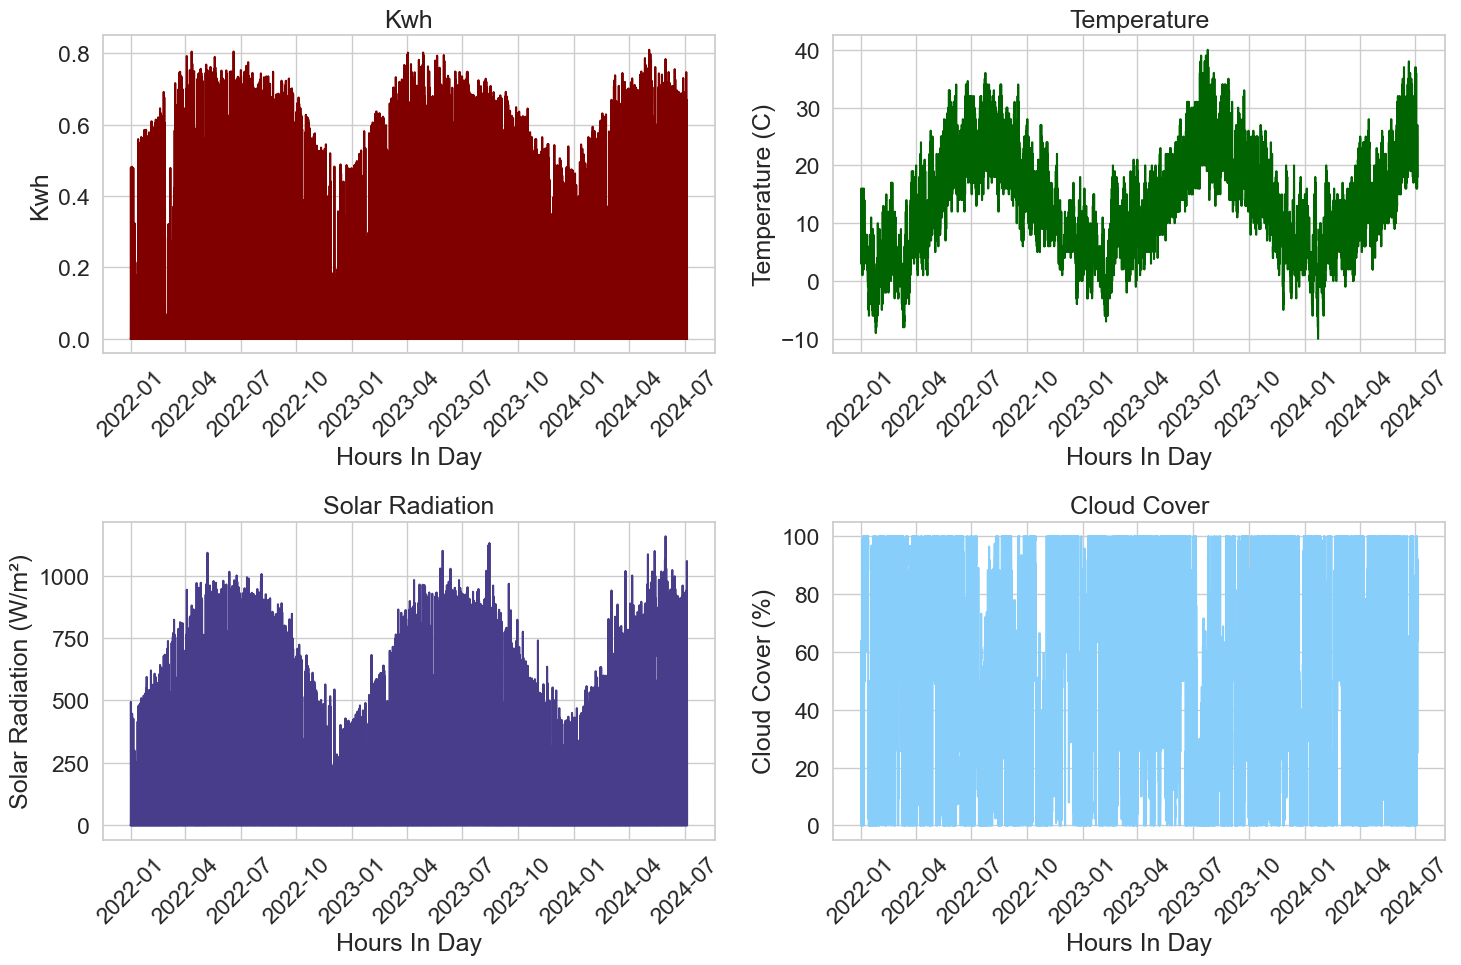

In [47]:
plt.figure(figsize=(16, 9))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.5)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
hours_in_day = data.index

axes[0, 0].plot(data.index, data['Kwh'], 'Maroon')
axes[0, 0].set_title('Kwh')
axes[0, 0].set_xlabel("Hours In Day")
axes[0, 0].set_ylabel('Kwh')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(data.index, data['temp'], 'DarkGreen')
axes[0, 1].set_title('Temperature')
axes[0, 1].set_xlabel("Hours In Day")
axes[0, 1].set_ylabel('Temperature (C)')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(data.index, data['solarradiation'], 'DarkSlateBlue')
axes[1, 0].set_title('Solar Radiation')
axes[1, 0].set_xlabel("Hours In Day")
axes[1, 0].set_ylabel('Solar Radiation (W/m²)')
axes[1, 0].tick_params(axis='x', rotation=45)


axes[1, 1].plot(data.index, data['cloudcover'], 'LightSkyBlue')
axes[1, 1].set_title('Cloud Cover')
axes[1, 1].set_xlabel("Hours In Day")
axes[1, 1].set_ylabel('Cloud Cover (%)')
axes[1, 1].tick_params(axis='x', rotation=45)


#fig.suptitle("Time Series Plots of 4 Features")
plt.tight_layout()
plt.show()

<Figure size 1600x900 with 0 Axes>

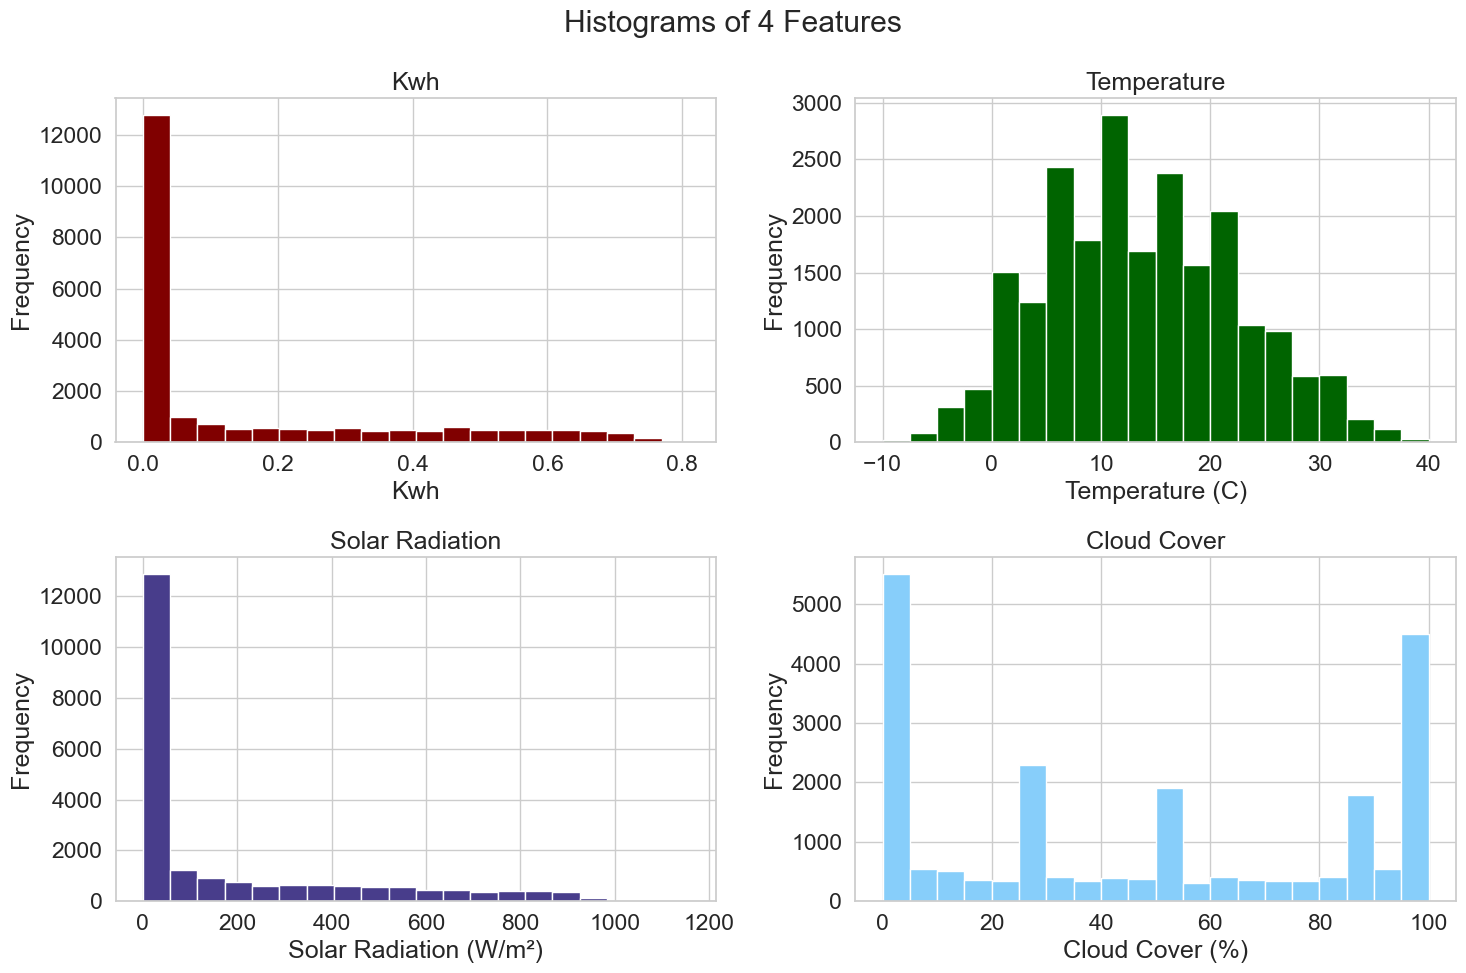

In [48]:
plt.figure(figsize=(16, 9))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(data['Kwh'], bins=20, color='Maroon')
axes[0, 0].set_title('Kwh')
axes[0, 0].set_xlabel("Kwh")
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(data['temp'], bins=20, color='DarkGreen')
axes[0, 1].set_title('Temperature')
axes[0, 1].set_xlabel("Temperature (C)")
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(data['solarradiation'], bins=20, color='DarkSlateBlue')
axes[1, 0].set_title('Solar Radiation')
axes[1, 0].set_xlabel("Solar Radiation (W/m²)")
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(data['cloudcover'], bins=20, color='LightSkyBlue')
axes[1, 1].set_title('Cloud Cover')
axes[1, 1].set_xlabel("Cloud Cover (%)")
axes[1, 1].set_ylabel('Frequency')

fig.suptitle("Histograms of 4 Features")
plt.tight_layout()
plt.show()


In [49]:
tc = data[["Kwh", "temp", "feelslike", "dew", "humidity", "windspeed", "winddir", "sealevelpressure", "cloudcover", "solarradiation", "solarenergy", "visibility", "snow", "snowdepth", "windgust", "uvindex"]].corr()

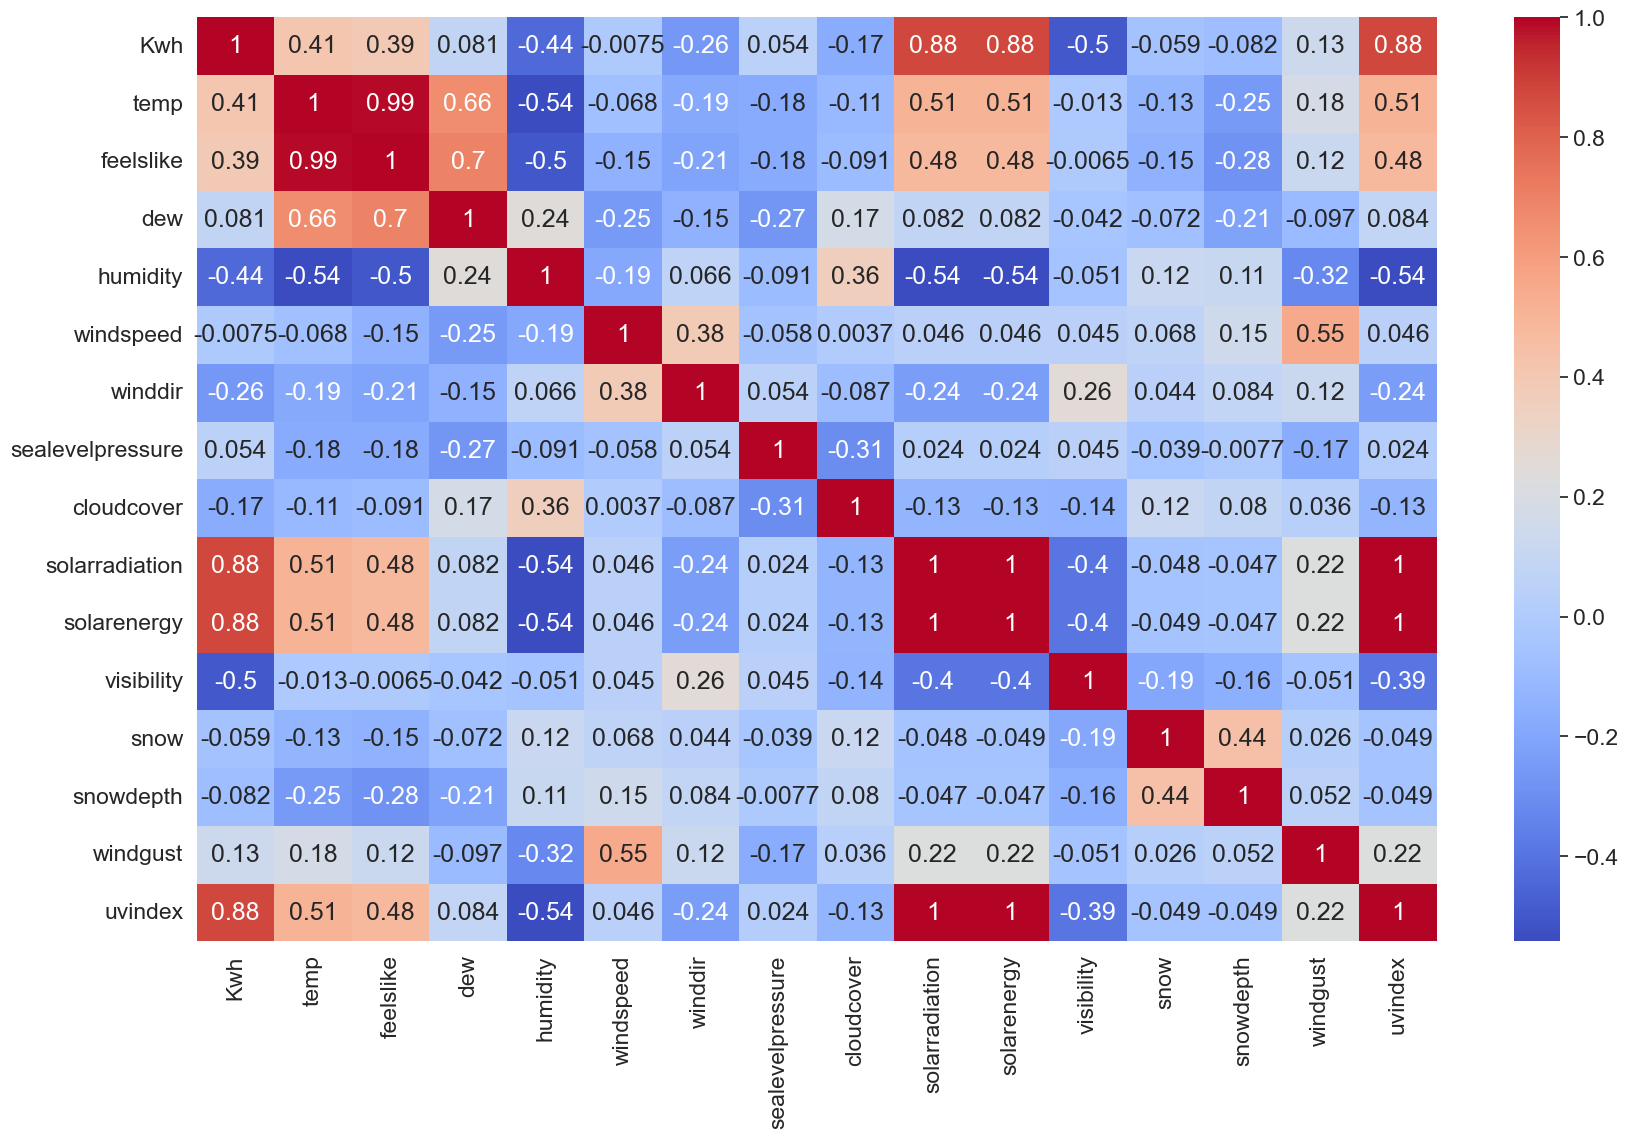

In [51]:
plt.figure(figsize= (20, 12))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.5)
sns.heatmap(tc, annot= True, cmap = "coolwarm")
plt.show()

# Regression Analysis

<Figure size 1600x900 with 0 Axes>

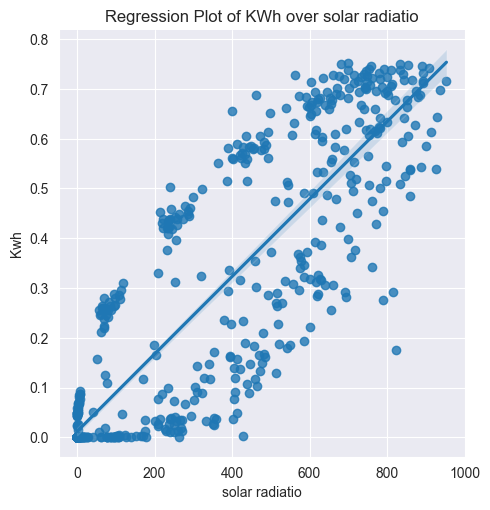

In [9]:
plt.figure(figsize= (16,9))
sns.set_style("darkgrid")
sns.lmplot(x = "solarradiation", y = "Kwh", data = data.iloc[5015:5735])
plt.title("Regression Plot of KWh over solar radiatio")
plt.xlabel("solar radiatio")
plt.ylabel("Kwh")
plt.show()

<Figure size 2000x900 with 0 Axes>

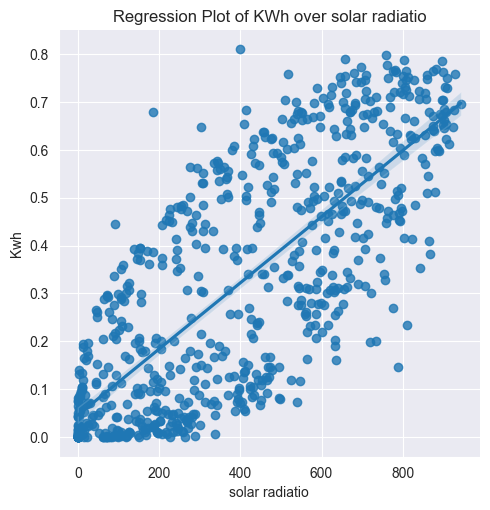

In [10]:
plt.figure(figsize= (20,9))
sns.set_style("darkgrid")
sns.lmplot(x = "solarradiation", y = "Kwh", data = data_non_zero.iloc[5015:5735])
plt.title("Regression Plot of KWh over solar radiatio")
plt.xlabel("solar radiatio")
plt.ylabel("Kwh")
plt.show()

In [35]:
from sklearn.linear_model import LinearRegression

y = data_non_zero['Kwh'].values
x = data_non_zero[['temp', 'humidity', 'winddir', 'cloudcover', 'solarradiation']].values

lm_model = LinearRegression()

lm_model.fit(x, y)

print(f"Intercept of the model is: {lm_model.intercept_} \nCoefficients of the Model are: {lm_model.coef_}")

Intercept of the model is: 0.07579773955549113 
Coefficients of the Model are: [-2.40622531e-03  1.54727376e-03 -5.66663117e-05 -1.33341964e-03
  7.33192124e-04]


$$ Y_{kwh} = 0.099798  - 0.00203 \cdot X_{temp} + 0.001251 \cdot X_{humidity} - 0.0000936 \cdot X_{winddir} - 0.001205 \cdot X_{cloudcover} + 0.0006909 \cdot X_{solarradiation} $$

In [36]:
import statsmodels.api as sm

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     7702.
Date:                Wed, 23 Oct 2024   Prob (F-statistic):               0.00
Time:                        15:38:01   Log-Likelihood:                 11185.
No. Observations:               19942   AIC:                        -2.236e+04
Df Residuals:                   19936   BIC:                        -2.231e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0758      0.006     13.591      0.000       0.065       0.087
x1            -0.0024      0.000    -16.621      0.000      -0.003      -0.002
x2             0.0015   6.22e-05     24.896      0.000       0.001       0.002
x3         -5.667e-05   7.16e-06     -7.911      0.000   -7.07e-05   -4.26e-05
x4            -0.0013   3.11e-05    -42.907      0.000      -0.001      -0.001
x5             0.0007   4.49e-06    163.237      0.000       0.001       0.001
==============================================================================
Omnibus:                      321.482   Durbin-Watson:                   0.692
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              540.488
Skew:                           0.137   Prob(JB):                    4.31e-118
Kurtosis:                       3.759   Cond. No.                     2.70e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.7e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [37]:
residuals = model.resid
fitted = model.fittedvalues  


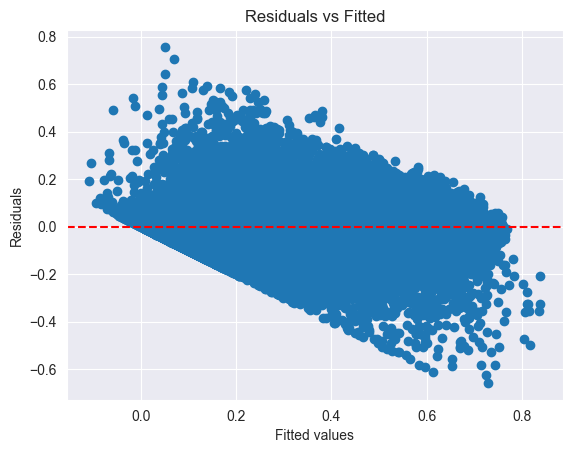

In [41]:
plt.scatter(fitted, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# Cluster Analysis 

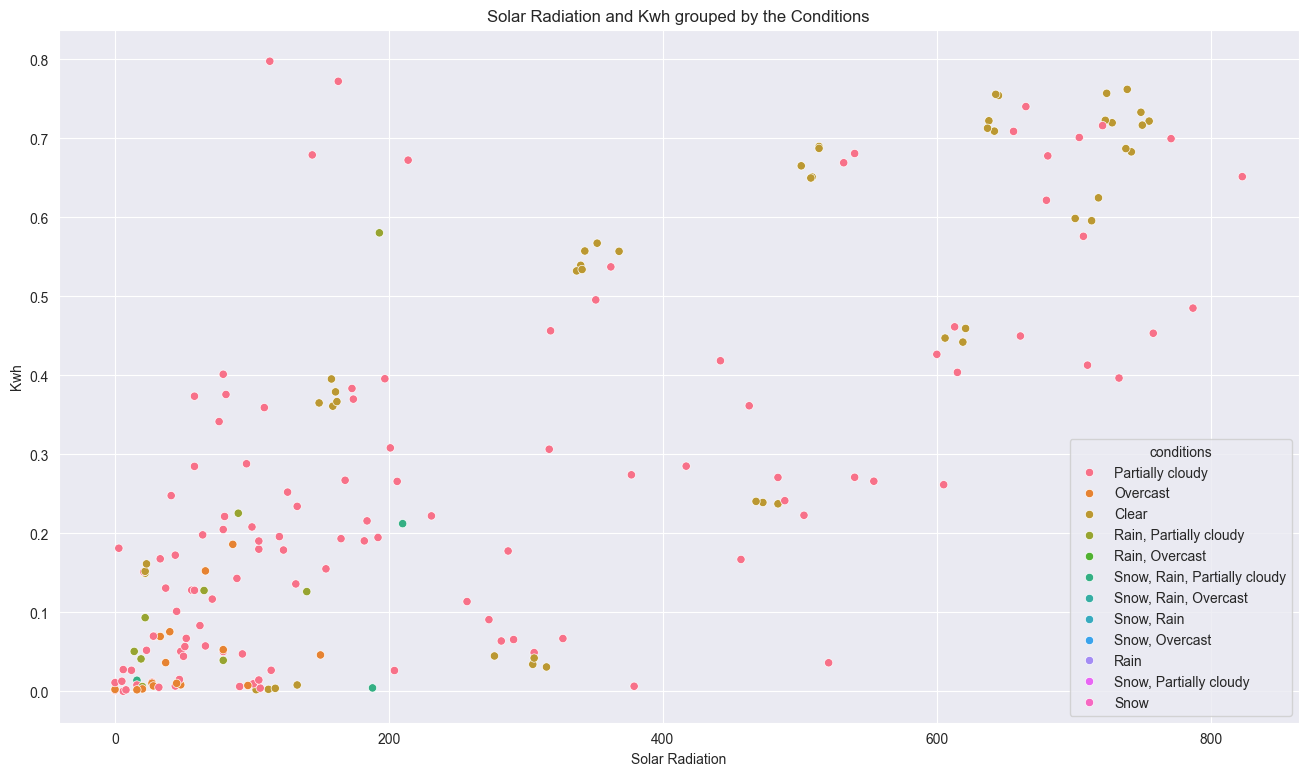

In [15]:
plt.figure(figsize= (16, 9))
sns.set_style('darkgrid')
sns.scatterplot(x = data_non_zero['solarradiation'][800: 1000], y = data_non_zero["Kwh"][800 : 1000], hue = data['conditions'])
plt.xlabel("Solar Radiation")
plt.ylabel("Kwh")
plt.title("Solar Radiation and Kwh grouped by the Conditions")
plt.show()

In [16]:
df_picked = data[['Kwh', 'temp', 'solarradiation', 'cloudcover']]

In [17]:
pd.set_option('display.float_format', '{:.6f}'.format)

In [18]:
df_grouped = df_picked.groupby(df_picked.index.hour).mean()
df_grouped = pd.DataFrame(df_grouped)
df_grouped

,Kwh,temp,solarradiation,cloudcover
datetime,,,,
0,0.000000,11.082635,0.018215,44.342441
1,0.000000,10.698239,0.018215,45.600729
2,0.000000,10.306740,0.018215,46.203704
3,0.000000,9.979587,0.015188,44.639793
4,0.000000,9.668063,0.015179,45.225804
5,0.000000,9.368063,0.021251,45.770553
6,0.001478,9.090043,0.621736,45.444384
7,0.038903,8.979599,11.292228,45.299939
8,0.158113,9.969763,70.367152,42.599879


In [19]:
type(df_grouped)

pandas.core.frame.DataFrame

<Figure size 1600x900 with 0 Axes>

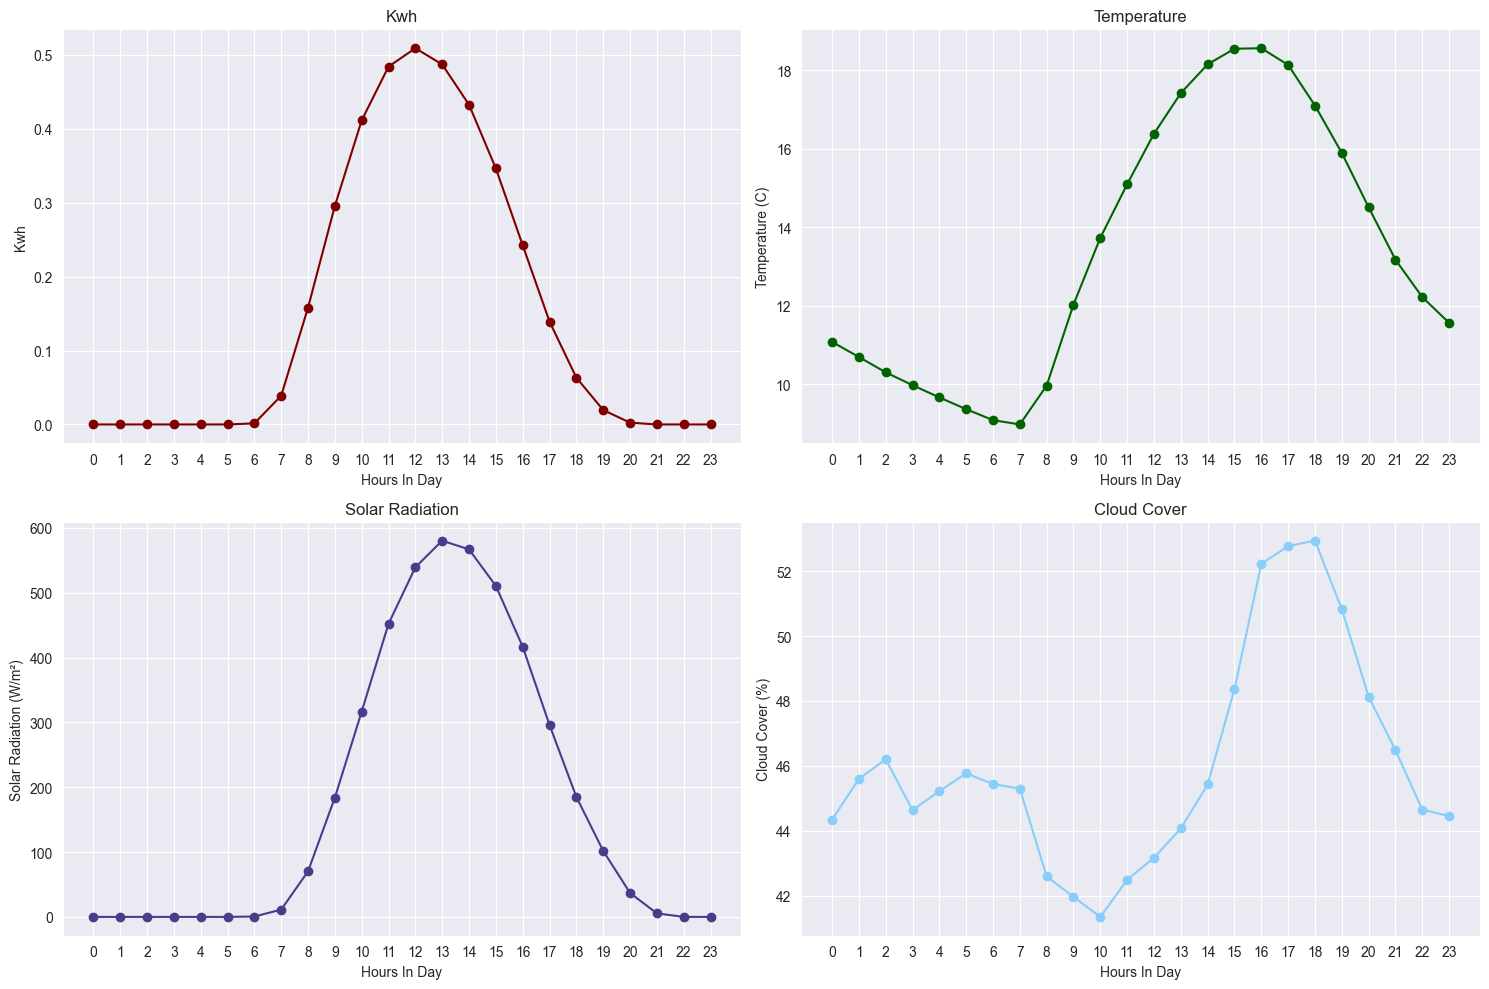

In [20]:
plt.figure(figsize=(16, 9))
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
hours_in_day = df_grouped.index

axes[0, 0].plot(df_grouped.index, df_grouped['Kwh'], 'Maroon', marker = 'o')
axes[0, 0].set_title('Kwh')
axes[0, 0].set_xlabel("Hours In Day")
axes[0, 0].set_ylabel('Kwh')
axes[0, 0].set_xticks(hours_in_day)

axes[0, 1].plot(df_grouped.index, df_grouped['temp'], 'DarkGreen', marker = 'o')
axes[0, 1].set_title('Temperature')
axes[0, 1].set_xlabel("Hours In Day")
axes[0, 1].set_ylabel('Temperature (C)')
axes[0, 1].set_xticks(hours_in_day)


axes[1, 0].plot(df_grouped.index, df_grouped['solarradiation'], 'DarkSlateBlue', marker = 'o')
axes[1, 0].set_title('Solar Radiation')
axes[1, 0].set_xlabel("Hours In Day")
axes[1, 0].set_ylabel('Solar Radiation (W/m²)')
axes[1, 0].set_xticks(hours_in_day)


axes[1, 1].plot(df_grouped.index, df_grouped['cloudcover'], 'LightSkyBlue', marker = 'o')
axes[1, 1].set_title('Cloud Cover')
axes[1, 1].set_xlabel("Hours In Day")
axes[1, 1].set_ylabel('Cloud Cover (%)')
axes[1, 1].set_xticks(hours_in_day)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Split to Winter and Summer

In [54]:
df_filtered_summer = df_picked[(df_picked.index.month >= 4) & (df_picked.index.month <= 9)]

df_filtered_winter = df_picked[(df_picked.index.month >= 10) | (df_picked.index.month <= 3)]

df_filtered_summer_grouped = df_filtered_summer.groupby(df_filtered_summer.index.hour).mean()
df_filtered_winter_grouped = df_filtered_winter.groupby(df_filtered_winter.index.hour).mean()

In [55]:
df_filtered_winter_grouped

,Kwh,temp,solarradiation,cloudcover
datetime,,,,
0,0.000000,5.702805,0.036585,50.172317
1,0.000000,5.458902,0.036585,51.020610
2,0.000000,5.143171,0.036585,52.880732
3,0.000000,4.916972,0.030525,52.803907
4,0.000000,4.636829,0.030488,54.523049
5,0.000000,4.436098,0.042683,55.344634
6,0.000131,4.311341,0.031707,54.835122
7,0.013077,4.099268,2.057927,54.000488
8,0.091976,4.333415,27.022439,51.071829


# Summer

<Figure size 1600x900 with 0 Axes>

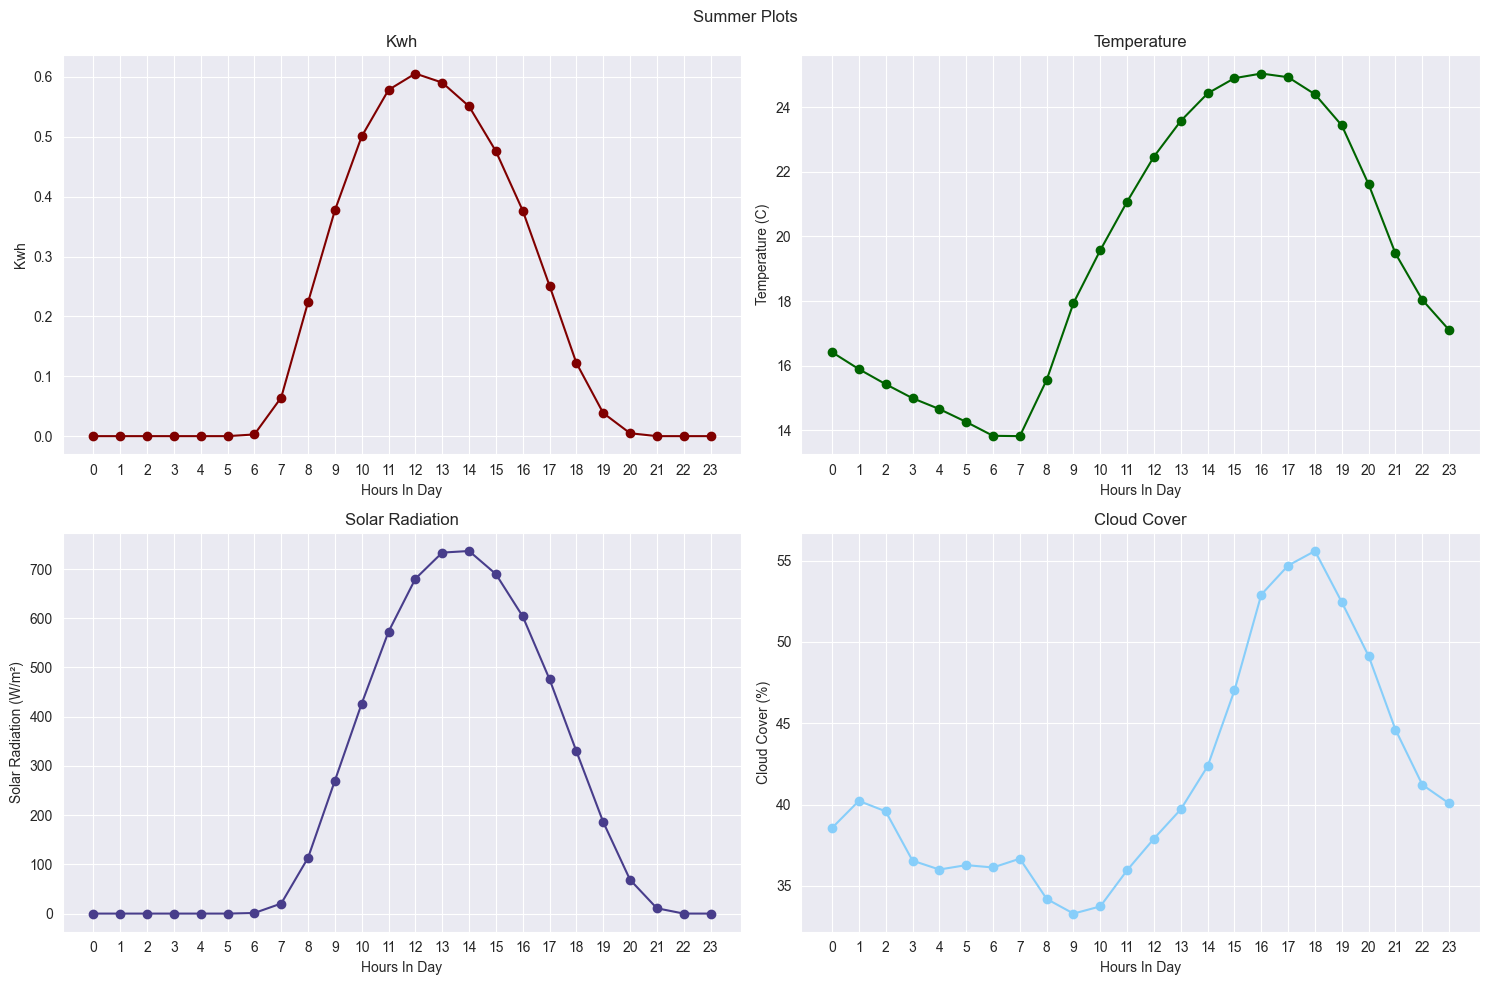

In [22]:
plt.figure(figsize=(16, 9))
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
hours_in_day = df_filtered_summer_grouped.index

axes[0, 0].plot(df_filtered_summer_grouped.index, df_filtered_summer_grouped['Kwh'], 'Maroon', marker = 'o')
axes[0, 0].set_title('Kwh')
axes[0, 0].set_xlabel("Hours In Day")
axes[0, 0].set_ylabel('Kwh')
axes[0, 0].set_xticks(hours_in_day)

axes[0, 1].plot(df_filtered_summer_grouped.index, df_filtered_summer_grouped['temp'], 'DarkGreen', marker = 'o')
axes[0, 1].set_title('Temperature')
axes[0, 1].set_xlabel("Hours In Day")
axes[0, 1].set_ylabel('Temperature (C)')
axes[0, 1].set_xticks(hours_in_day)


axes[1, 0].plot(df_filtered_summer_grouped.index, df_filtered_summer_grouped['solarradiation'], 'DarkSlateBlue', marker = 'o')
axes[1, 0].set_title('Solar Radiation')
axes[1, 0].set_xlabel("Hours In Day")
axes[1, 0].set_ylabel('Solar Radiation (W/m²)')
axes[1, 0].set_xticks(hours_in_day)


axes[1, 1].plot(df_filtered_summer_grouped.index, df_filtered_summer_grouped['cloudcover'], 'LightSkyBlue', marker = 'o')
axes[1, 1].set_title('Cloud Cover')
axes[1, 1].set_xlabel("Hours In Day")
axes[1, 1].set_ylabel('Cloud Cover (%)')
axes[1, 1].set_xticks(hours_in_day)

fig.suptitle("Summer Plots")
plt.tight_layout()
plt.show()

# Winter

<Figure size 1600x900 with 0 Axes>

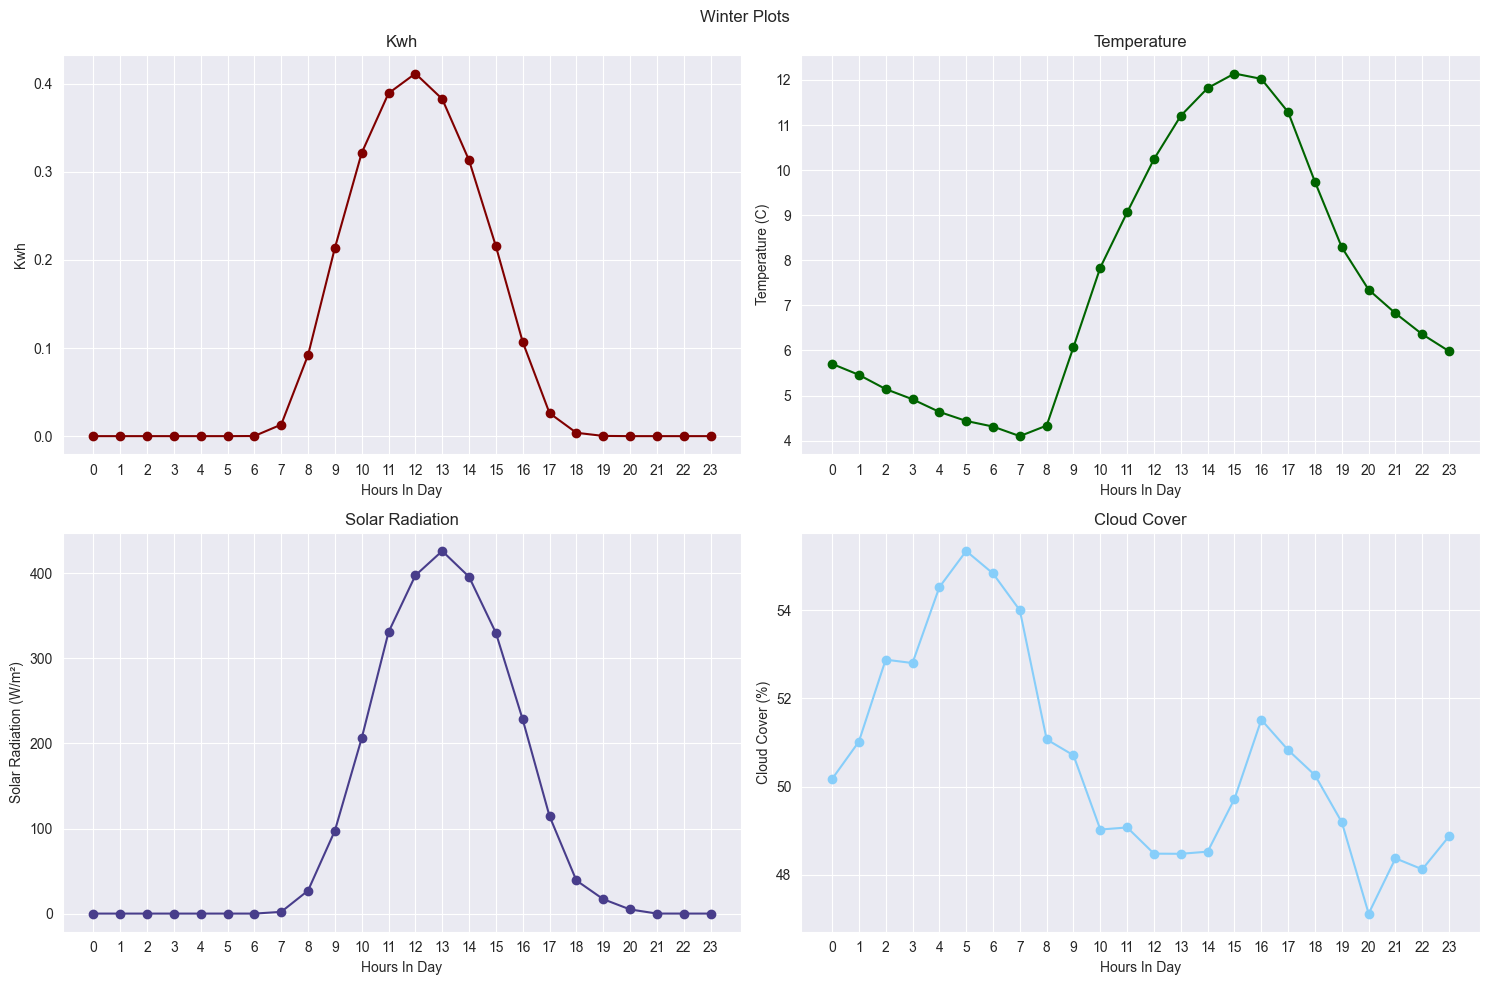

In [23]:
plt.figure(figsize=(16, 9))
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

hours_in_day = df_filtered_winter_grouped.index

axes[0, 0].plot(df_filtered_winter_grouped.index, df_filtered_winter_grouped['Kwh'], 'Maroon', marker = 'o')
axes[0, 0].set_title('Kwh')
axes[0, 0].set_xlabel("Hours In Day")
axes[0, 0].set_ylabel('Kwh')
axes[0, 0].set_xticks(hours_in_day)

axes[0, 1].plot(df_filtered_winter_grouped.index, df_filtered_winter_grouped['temp'], 'DarkGreen', marker = 'o')
axes[0, 1].set_title('Temperature')
axes[0, 1].set_xlabel("Hours In Day")
axes[0, 1].set_ylabel('Temperature (C)')
axes[0, 1].set_xticks(hours_in_day)


axes[1, 0].plot(df_filtered_winter_grouped.index, df_filtered_winter_grouped['solarradiation'], 'DarkSlateBlue', marker = 'o')
axes[1, 0].set_title('Solar Radiation')
axes[1, 0].set_xlabel("Hours In Day")
axes[1, 0].set_ylabel('Solar Radiation (W/m²)')
axes[1, 0].set_xticks(hours_in_day)


axes[1, 1].plot(df_filtered_winter_grouped.index, df_filtered_winter_grouped['cloudcover'], 'LightSkyBlue', marker = 'o')
axes[1, 1].set_title('Cloud Cover')
axes[1, 1].set_xlabel("Hours In Day")
axes[1, 1].set_ylabel('Cloud Cover (%)')
axes[1, 1].set_xticks(hours_in_day)

fig.suptitle("Winter Plots")
plt.tight_layout()
plt.show()